# Machine Learning-Driven Image Segmentation
## K-means Clustering Approach


This notebook implements image segmentation using K-means clustering to group pixels based on color similarity.

## 1. Import Required Libraries

In [1]:
%pip install scikit-image

import numpy as np
import cv2
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.utils import shuffle
import os
from skimage import data

os.makedirs("segmentation_results", exist_ok=True)


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: C:\Users\USER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



## 2. Load Sample Image

For demonstration, we'll use a sample image. You can replace this with your own image path.

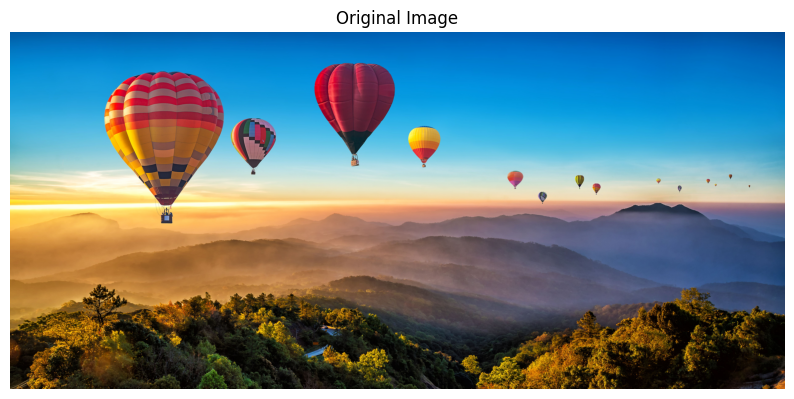

Image shape: (3393, 7360, 3)


In [2]:
image_path = "Ballon.jpg"  

# Display the original image
original_image = cv2.imread(image_path)
original_image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(original_image_rgb)
plt.title('Original Image')
plt.axis('off')
plt.show()

print(f"Image shape: {original_image_rgb.shape}")

## 3. Basic Image Segmentation using K-means

### 3.1.1 Load and 3.1.2 Preprocess the Image

In [3]:
# Step 3.1.1 & 3.1.2: Load and preprocess the image

image = original_image_rgb.copy()
height, width, channels = image.shape
print(f"Working with image dimensions: {width}x{height} with {channels} channels")

Working with image dimensions: 7360x3393 with 3 channels


### 3.1.3 Convert Image to Suitable Format for K-means

In [4]:
# Step 3.1.3: Convert the image into a suitable format for K-means clustering

# Reshape the image to a 2D array of pixels (each row is a pixel with RGB values)
pixel_samples = image.reshape((-1, channels))
print(f"Reshaped to {pixel_samples.shape[0]} pixels with {pixel_samples.shape[1]} features (RGB)")

# To improve performance, we can use a subset of pixels for clustering
# For large images, sample a subset of pixels
if pixel_samples.shape[0] > 10000:
    pixel_samples_subset = shuffle(pixel_samples, random_state=0)[:10000]
    print(f"Sampled {pixel_samples_subset.shape[0]} pixels for faster clustering")
else:
    pixel_samples_subset = pixel_samples
    print("Using all pixels for clustering")

Reshaped to 24972480 pixels with 3 features (RGB)
Sampled 10000 pixels for faster clustering


### 3.1.4 & 3.1.5 Choose the Number of Clusters and Apply K-means

In [5]:
# Step 3.1.4 & 3.1.5: Choose number of clusters and apply K-means

# Set the number of clusters (K)
n_clusters = 5
init_type = 'k-means++'

print(f"Applying K-means with {n_clusters} clusters and '{init_type}' initialization...")

# Apply K-means clustering
kmeans = KMeans(n_clusters=n_clusters, init=init_type, n_init=10, random_state=0)
kmeans.fit(pixel_samples_subset)

# Apply the learned model to all pixels
labels = kmeans.predict(pixel_samples)
print("Clustering complete!")

Applying K-means with 5 clusters and 'k-means++' initialization...
Clustering complete!


### 3.1.6 Assign Labels to Clusters

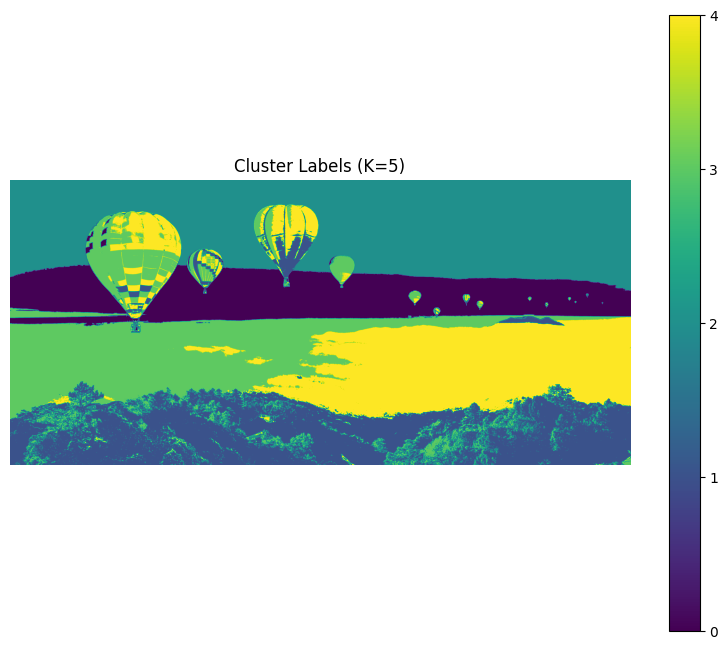

In [6]:
# Step 3.1.6: Assign labels to clusters

# Reshape the labels to match the image dimensions
labels_reshaped = labels.reshape(height, width)

# Display the labels as an image (each cluster gets a different color)
plt.figure(figsize=(10, 8))
plt.imshow(labels_reshaped, cmap='viridis')
plt.title(f'Cluster Labels (K={n_clusters})')
plt.colorbar(ticks=range(n_clusters))
plt.axis('off')
plt.show()

### 3.1.7 Create Segmented Image

In [7]:
# Step 3.1.7: Create segmented image by replacing each pixel with its centroid

# Create an empty image with the same shape as the original
segmented_image = np.zeros_like(image)

# Replace each pixel with its corresponding cluster centroid
for i in range(n_clusters):
    segmented_image[labels_reshaped == i] = kmeans.cluster_centers_[i]

# Ensure pixel values are within valid range and convert to uint8
segmented_image = np.clip(segmented_image, 0, 255).astype(np.uint8)

### 3.1.8 Display and Save Segmented Image

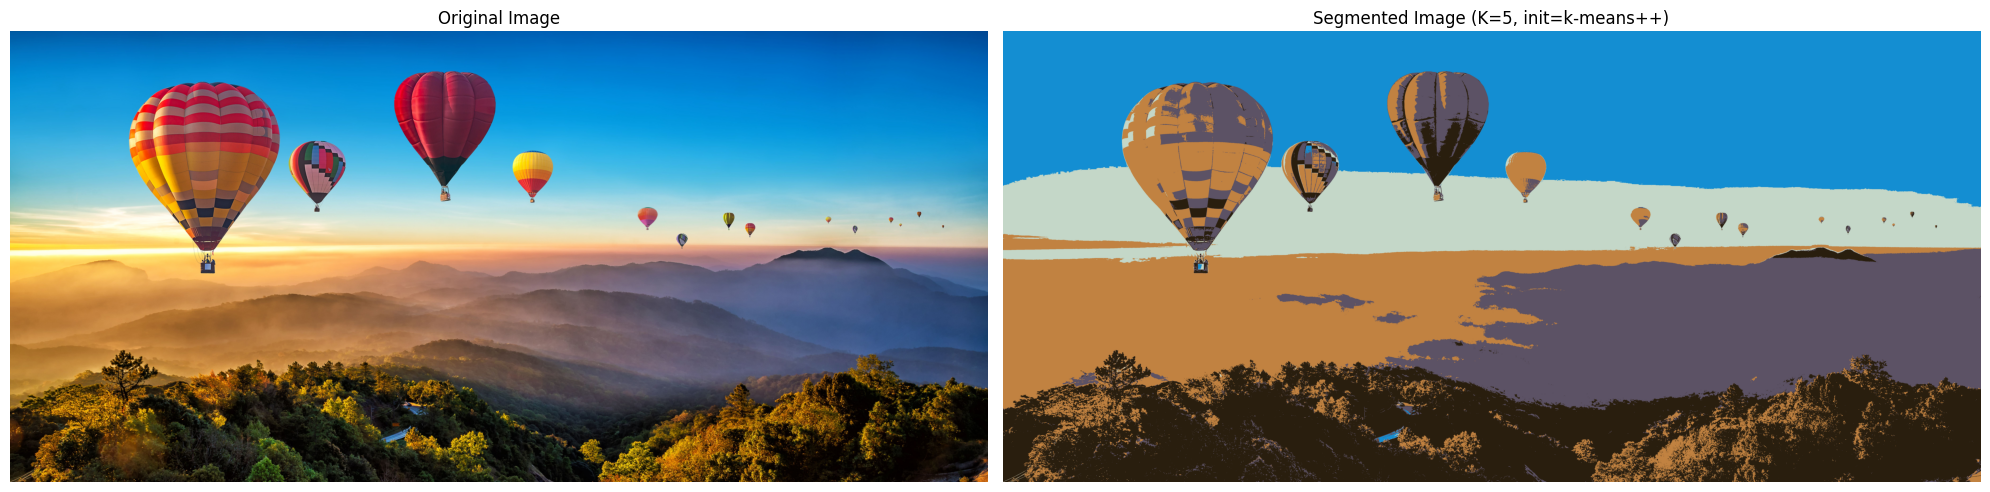

Segmented image saved to segmentation_results/segmented_k5.jpg


In [8]:
# Step 3.1.8: Display and save segmented image

# Display original and segmented images side by side
plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(segmented_image)
plt.title(f'Segmented Image (K={n_clusters}, init={init_type})')
plt.axis('off')

plt.tight_layout()
plt.show()

# Save the segmented image
save_path = "segmentation_results/segmented_k5.jpg"
cv2.imwrite(save_path, cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR))
print(f"Segmented image saved to {save_path}")

## 3.1.9 Vary Parameters and Observe Results

### A. Varying the Number of Clusters

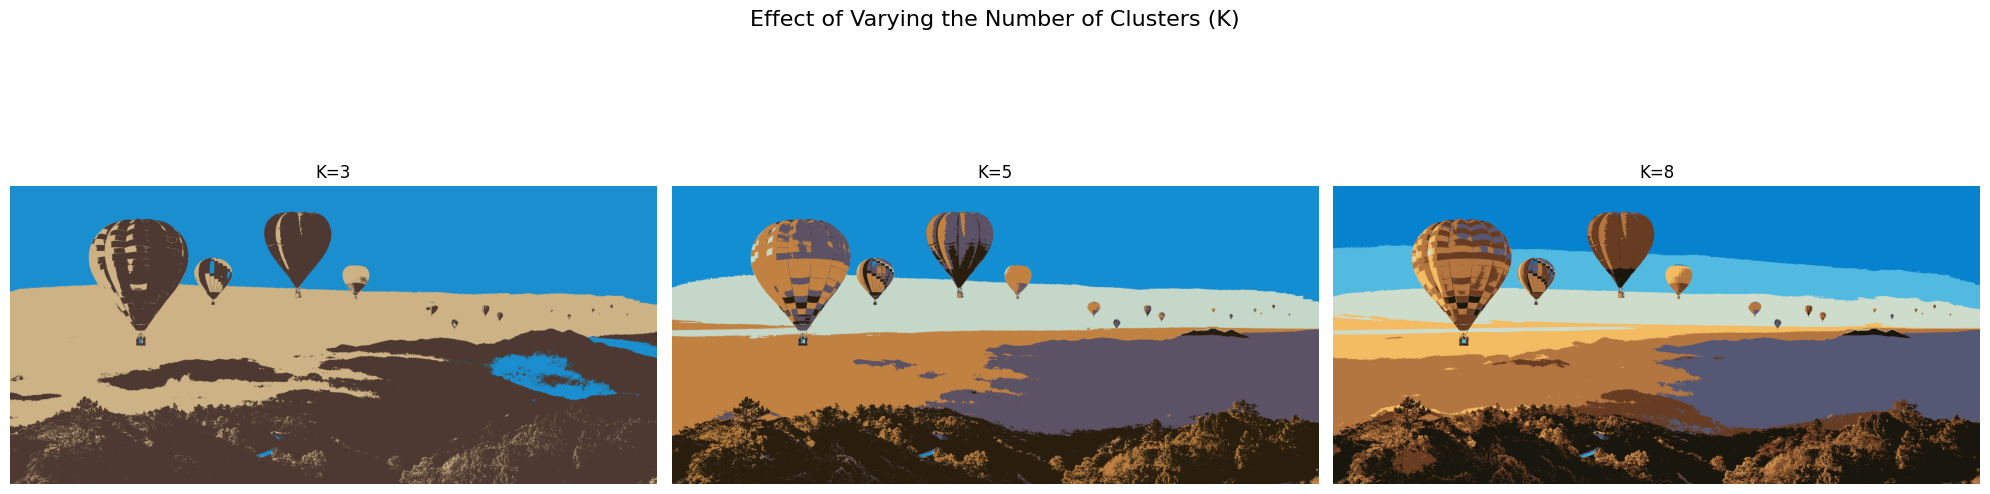

In [9]:
# Vary the number of clusters
cluster_values = [3, 5, 8]

plt.figure(figsize=(20, 6))

for i, k in enumerate(cluster_values):
    # Apply K-means with different number of clusters
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=0)
    kmeans.fit(pixel_samples_subset)
    labels = kmeans.predict(pixel_samples)
    labels_reshaped = labels.reshape(height, width)
    
    # Create segmented image
    segmented = np.zeros_like(image)
    for j in range(k):
        segmented[labels_reshaped == j] = kmeans.cluster_centers_[j]
    segmented = np.clip(segmented, 0, 255).astype(np.uint8)
    
    # Display segmented image
    plt.subplot(1, 3, i+1)
    plt.imshow(segmented)
    plt.title(f'K={k}')
    plt.axis('off')
    
    # Save segmented image
    save_path = f"segmentation_results/segmented_k{k}.jpg"
    cv2.imwrite(save_path, cv2.cvtColor(segmented, cv2.COLOR_RGB2BGR))

plt.tight_layout()
plt.suptitle('Effect of Varying the Number of Clusters (K)', fontsize=16)
plt.subplots_adjust(top=0.85)
plt.show()

### B. Varying the Initialization Type

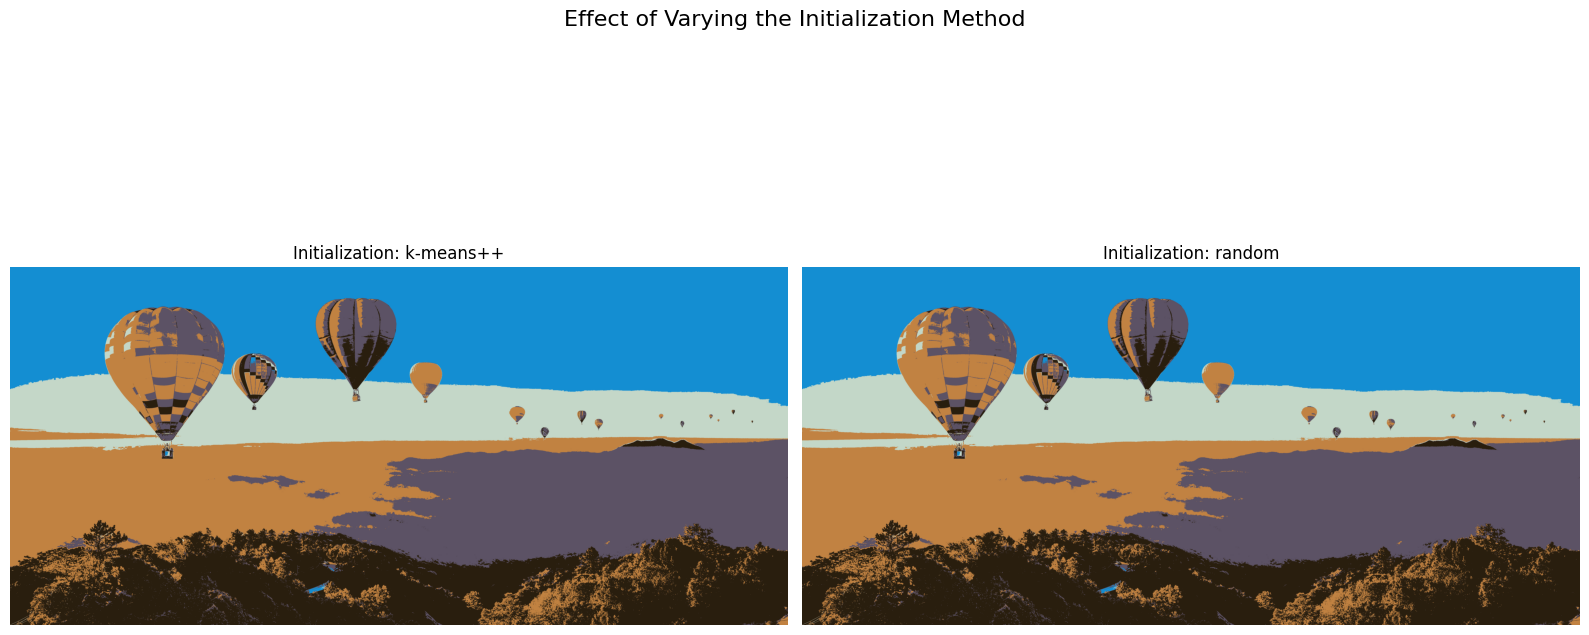

In [10]:
# Vary the initialization type
init_types = ['k-means++', 'random']
k = 5  # Fix number of clusters

plt.figure(figsize=(16, 8))

for i, init in enumerate(init_types):
    # Apply K-means with different initialization
    kmeans = KMeans(n_clusters=k, init=init, n_init=10, random_state=0)
    kmeans.fit(pixel_samples_subset)
    labels = kmeans.predict(pixel_samples)
    labels_reshaped = labels.reshape(height, width)
    
    # Create segmented image
    segmented = np.zeros_like(image)
    for j in range(k):
        segmented[labels_reshaped == j] = kmeans.cluster_centers_[j]
    segmented = np.clip(segmented, 0, 255).astype(np.uint8)
    
    # Display segmented image
    plt.subplot(1, 2, i+1)
    plt.imshow(segmented)
    plt.title(f'Initialization: {init}')
    plt.axis('off')
    
    # Save segmented image
    save_path = f"segmentation_results/segmented_init_{init}.jpg"
    cv2.imwrite(save_path, cv2.cvtColor(segmented, cv2.COLOR_RGB2BGR))

plt.tight_layout()
plt.suptitle('Effect of Varying the Initialization Method', fontsize=16)
plt.subplots_adjust(top=0.85)
plt.show()

### C. Varying the Distance Metric

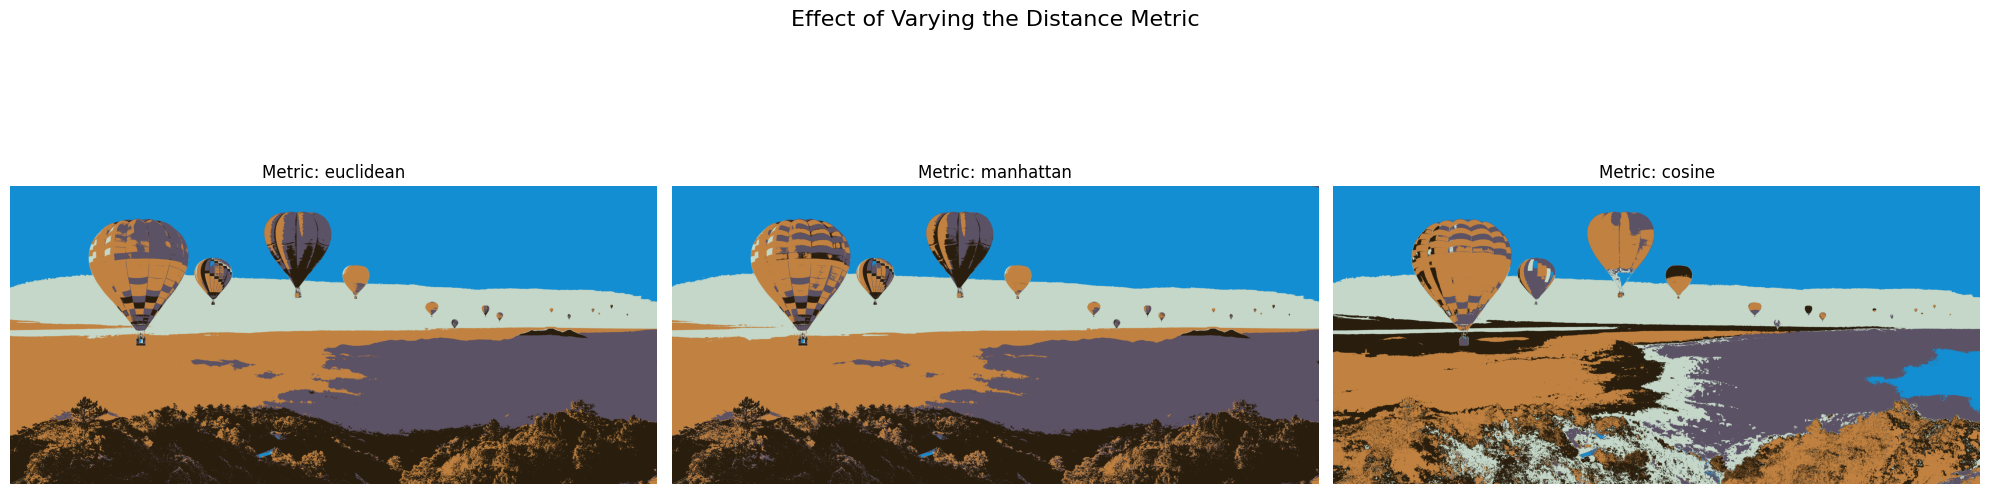

In [11]:
# Vary the distance metric
distance_metrics = ['euclidean', 'manhattan', 'cosine']
k = 5  # Fix number of clusters
init = 'k-means++'  # Fix initialization

plt.figure(figsize=(20, 6))

# First, train K-means with default euclidean distance
kmeans = KMeans(n_clusters=k, init=init, n_init=10, random_state=0)
kmeans.fit(pixel_samples_subset)
centers = kmeans.cluster_centers_

for i, metric in enumerate(distance_metrics):
    if metric == 'euclidean':
        # Use the KMeans predict for euclidean
        labels = kmeans.predict(pixel_samples)
    else:
        # For non-euclidean metrics, calculate distances manually
        distances = pairwise_distances(pixel_samples, centers, metric=metric)
        labels = np.argmin(distances, axis=1)
    
    labels_reshaped = labels.reshape(height, width)
    
    # Create segmented image
    segmented = np.zeros_like(image)
    for j in range(k):
        segmented[labels_reshaped == j] = centers[j]
    segmented = np.clip(segmented, 0, 255).astype(np.uint8)
    
    # Display segmented image
    plt.subplot(1, 3, i+1)
    plt.imshow(segmented)
    plt.title(f'Metric: {metric}')
    plt.axis('off')
    
    # Save segmented image
    save_path = f"segmentation_results/segmented_metric_{metric}.jpg"
    cv2.imwrite(save_path, cv2.cvtColor(segmented, cv2.COLOR_RGB2BGR))

plt.tight_layout()
plt.suptitle('Effect of Varying the Distance Metric', fontsize=16)
plt.subplots_adjust(top=0.85)
plt.show()

## Conclusion and Analysis

In this notebook, we implemented image segmentation using K-means clustering as specified in the assignment. We explored how different parameters affect segmentation quality:

1. **Number of clusters (K)**:
   - Lower K values create more general segments
   - Higher K values create more detailed segmentation but may over-segment

2. **Initialization method**:
   - 'k-means++' typically provides better and more consistent results than 'random'
   - Random initialization may produce different results each run

3. **Distance metric**:
   - Euclidean: Standard distance measure, works well for color spaces
   - Manhattan: Less sensitive to outliers, creates different boundaries
   - Cosine: Focuses on direction rather than magnitude, good for color direction

The results demonstrate how K-means clustering can effectively segment images based on color similarity, and how parameter tuning affects the segmentation outcome.

## 3.2 Image Segmentation Using Data Classification (SVM)

In this section, we'll implement image segmentation using a Support Vector Machine (SVM) classifier.

### 3.2.1 Load an Example Image

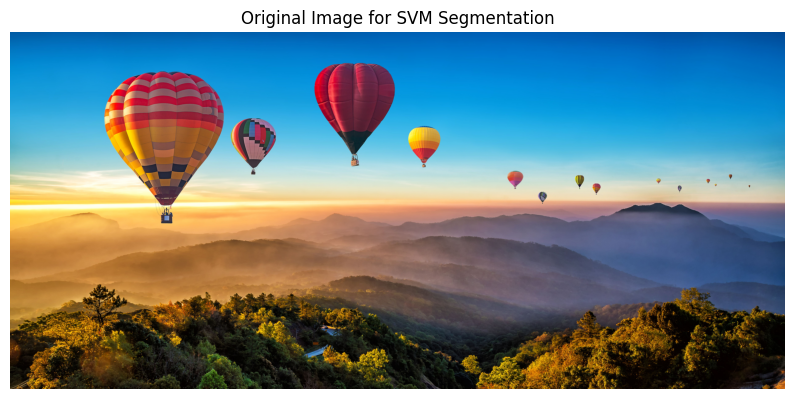

In [12]:
# We can use the same image from before or load a new one

image_path = "Ballon.jpg"
original_image = cv2.imread(image_path)
original_image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(original_image_rgb)
plt.title('Original Image for SVM Segmentation')
plt.axis('off')
plt.show()

### 3.2.2 Convert the Image to Grayscale and Create a Binary Mask

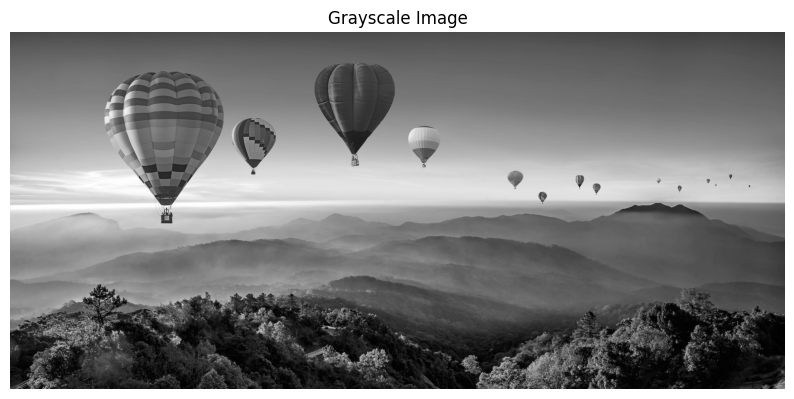

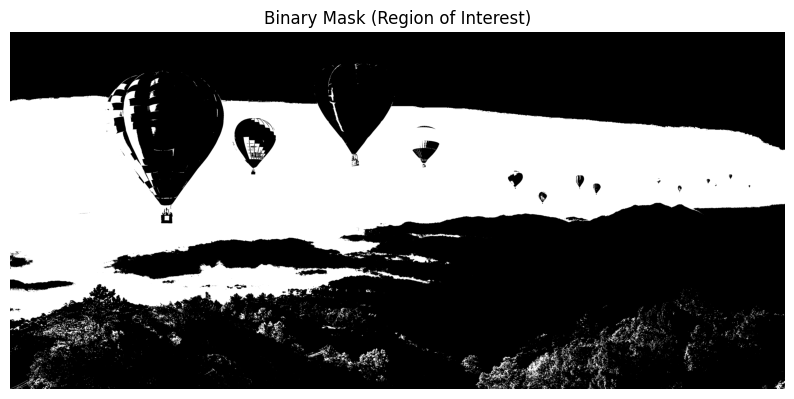

Grayscale conversion and mask creation complete.


In [13]:
# Convert the image to grayscale
gray_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)

# Display the grayscale image
plt.figure(figsize=(10, 8))
plt.imshow(gray_image, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')
plt.show()

# Create a binary mask for the region of interest
# For demonstration, we'll create a simple mask based on thresholding
# In a real application, this could be created manually or through another segmentation method

# Simple thresholding
_, binary_mask = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)


# Display the binary mask
plt.figure(figsize=(10, 8))
plt.imshow(binary_mask, cmap='gray')
plt.title('Binary Mask (Region of Interest)')
plt.axis('off')
plt.show()

print("Grayscale conversion and mask creation complete.")

### 3.2.3 Extract Features from the Grayscale Image

In [14]:
# Import additional libraries for feature extraction
from skimage.feature import hog
from scipy import ndimage as ndi
import numpy as np

def extract_features(gray_img):
    """Extract features from grayscale image for SVM classification"""
    
    # Get image dimensions
    height, width = gray_img.shape
    
    # Initialize feature matrix
    features = np.zeros((height * width, 6))
    
    # Feature 1: Pixel intensity (normalized)
    features[:, 0] = gray_img.flatten() / 255.0
    
    # Feature 2 & 3: Sobel gradients (X and Y)
    sobel_x = ndi.sobel(gray_img, axis=0)
    sobel_y = ndi.sobel(gray_img, axis=1)
    features[:, 1] = sobel_x.flatten() / np.max(np.abs(sobel_x))
    features[:, 2] = sobel_y.flatten() / np.max(np.abs(sobel_y))
    
    # Feature 4: Gradient magnitude
    gradient_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
    features[:, 3] = gradient_magnitude.flatten() / np.max(gradient_magnitude)
    
    # Feature 5: Laplacian (edge detector)
    laplacian = ndi.laplace(gray_img)
    features[:, 4] = laplacian.flatten() / np.max(np.abs(laplacian))
    
    # Feature 6: Gaussian filter (blurred version)
    gaussian = ndi.gaussian_filter(gray_img, sigma=2)
    features[:, 5] = gaussian.flatten() / 255.0
    
    return features

# Extract features from the grayscale image
print("Extracting features...")
features = extract_features(gray_image)

# Flatten the binary mask to use as labels
labels = (binary_mask.flatten() > 128).astype(np.int32)

print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Number of positive (foreground) pixels: {np.sum(labels == 1)}")
print(f"Number of negative (background) pixels: {np.sum(labels == 0)}")

Extracting features...
Features shape: (24972480, 6)
Labels shape: (24972480,)
Number of positive (foreground) pixels: 8675852
Number of negative (background) pixels: 16296628


### 3.2.4 Split the Data into Training and Testing Sets

In [15]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# We'll use 20% of the data for testing
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42
)

print(f"Training features shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Testing labels shape: {y_test.shape}")

Training features shape: (19977984, 6)
Training labels shape: (19977984,)
Testing features shape: (4994496, 6)
Testing labels shape: (4994496,)


### 3.2.5 Create an SVM Classifier and Train It

In [16]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Create SVM classifier
# Using a pipeline with StandardScaler to normalize features
# Note: For large images, you might want to use LinearSVC instead of SVC for faster training
print("Training SVM classifier...")

# For faster training on large images, we can use a subset of the training data
# Adjust sample_size based on your image size and available memory
sample_size = min(10000, X_train.shape[0])
random_indices = np.random.choice(X_train.shape[0], sample_size, replace=False)
X_train_subset = X_train[random_indices]
y_train_subset = y_train[random_indices]

print(f"Using {sample_size} samples for training")

# Create and train the SVM model
svm_model = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', probability=True)
)

# Train the model
svm_model.fit(X_train_subset, y_train_subset)

print("SVM training complete!")

Training SVM classifier...
Using 10000 samples for training
SVM training complete!


### 3.2.6 Predict on Test Data and Segment the Image

Test accuracy: 0.9945

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00   3258588
           1       0.99      0.99      0.99   1735908

    accuracy                           0.99   4994496
   macro avg       0.99      0.99      0.99   4994496
weighted avg       0.99      0.99      0.99   4994496

Segmenting the entire image...


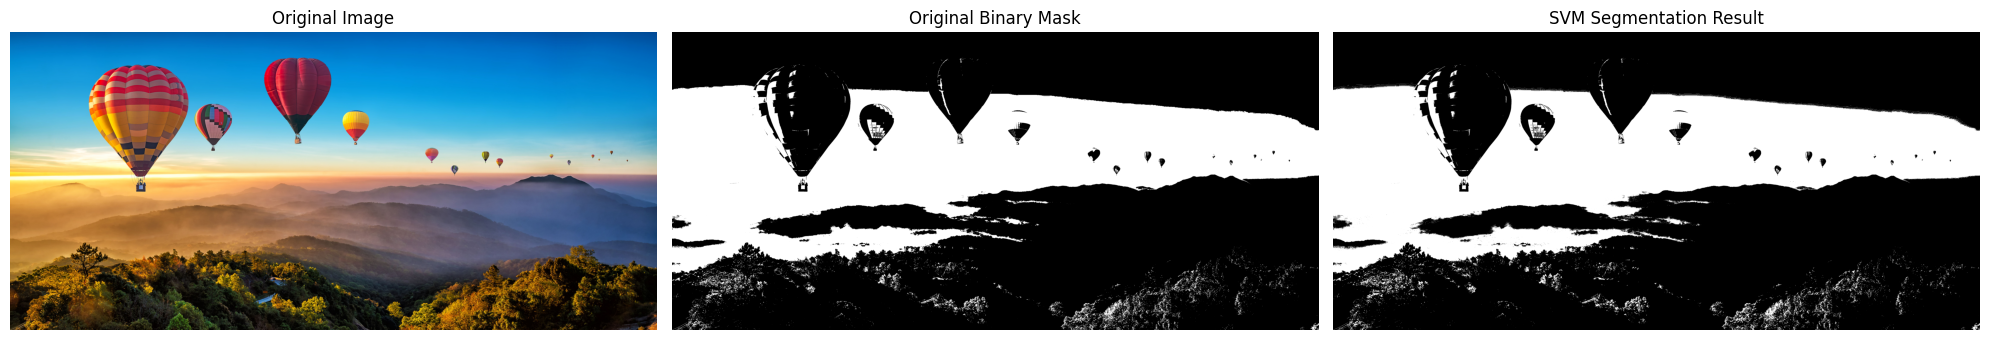

SVM segmented mask saved to 'segmentation_results/svm_segmented_mask.jpg'


In [17]:
from sklearn.metrics import accuracy_score, classification_report

# Predict on the test data
y_pred = svm_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.4f}")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Now, use the trained model to segment the entire image
print("Segmenting the entire image...")

# Predict on all pixels
all_predictions = svm_model.predict(features)

# Reshape predictions back to image dimensions
segmented_mask = all_predictions.reshape(gray_image.shape)

# Display the segmentation result
plt.figure(figsize=(20, 10))

plt.subplot(1, 3, 1)
plt.imshow(original_image_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(binary_mask, cmap='gray')
plt.title('Original Binary Mask')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(segmented_mask, cmap='gray')
plt.title('SVM Segmentation Result')
plt.axis('off')

plt.tight_layout()
plt.show()

# Save the segmented mask
segmented_mask_uint8 = (segmented_mask * 255).astype(np.uint8)
cv2.imwrite("segmentation_results/svm_segmented_mask.jpg", segmented_mask_uint8)
print("SVM segmented mask saved to 'segmentation_results/svm_segmented_mask.jpg'")

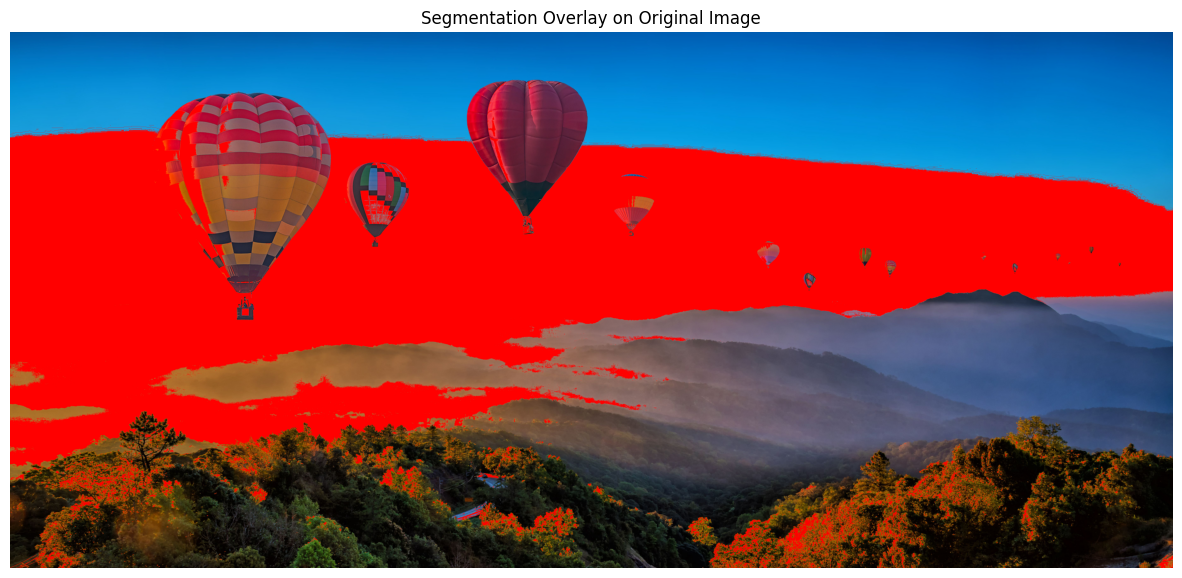

Segmentation overlay saved to 'segmentation_results/svm_segmentation_overlay.jpg'


In [18]:
# Create a colored overlay of the segmentation result on the original image
segmented_overlay = original_image_rgb.copy()

# Create a mask for the segmented region
mask = segmented_mask.astype(bool)

# Set segmented region to a specific color (e.g., red)
segmented_overlay[mask, 0] = 255  # Red channel
segmented_overlay[mask, 1] = 0    # Green channel
segmented_overlay[mask, 2] = 0    # Blue channel

# Display the overlay
plt.figure(figsize=(15, 10))
plt.imshow(segmented_overlay)
plt.title('Segmentation Overlay on Original Image')
plt.axis('off')
plt.show()

# Save the overlay
cv2.imwrite(
    "segmentation_results/svm_segmentation_overlay.jpg", 
    cv2.cvtColor(segmented_overlay, cv2.COLOR_RGB2BGR)
)
print("Segmentation overlay saved to 'segmentation_results/svm_segmentation_overlay.jpg'")

## 4. Comparison of K-means and SVM Segmentation Methods

Now let's compare the results of our two segmentation approaches:

1. **K-means Clustering** (Unsupervised):
   - Segments based on color similarity
   - Does not require labeled training data
   - Results in multiple segments (based on K value)
   - Works well for color-based segmentation

2. **SVM Classification** (Supervised):
   - Segments based on feature similarity to training data
   - Requires labeled training data (binary mask)
   - Results in binary segmentation (foreground/background)
   - Can incorporate multiple features beyond just color

The choice between these methods depends on:
- Whether labeled training data is available
- The specific segmentation task requirements
- The nature of the image and regions to be segmented

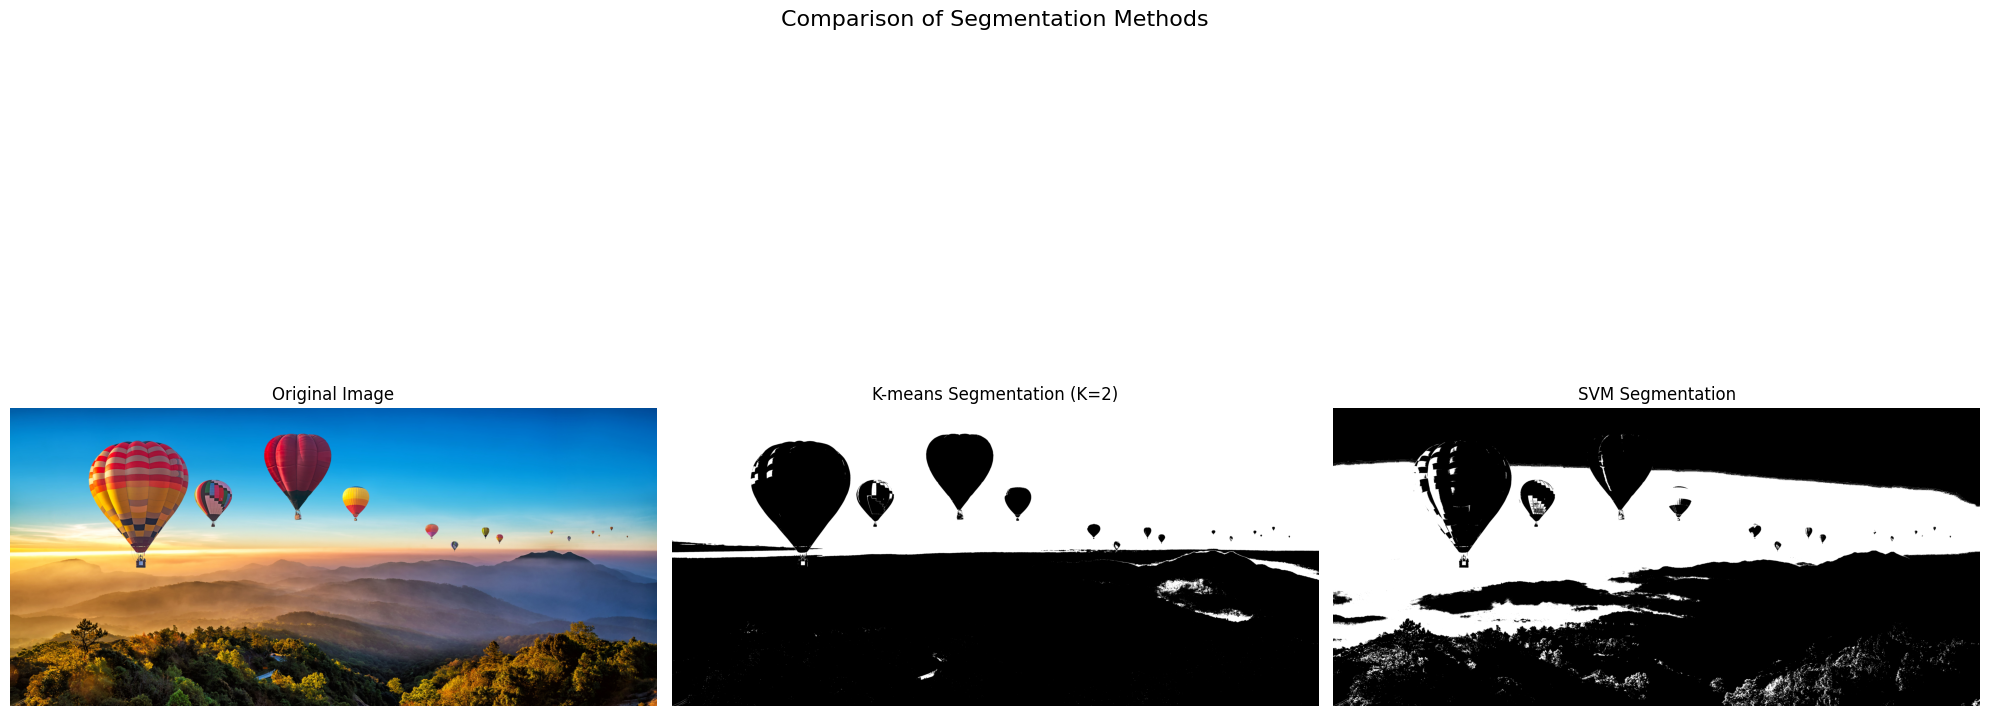

Comparison complete. Results saved to segmentation_results directory.


In [19]:
# Get the K-means segmentation result with K=2 for comparison
# Since SVM gives binary segmentation, we'll use K=2 for fair comparison
kmeans = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=0)
kmeans.fit(pixel_samples_subset)
kmeans_labels = kmeans.predict(pixel_samples)
kmeans_labels_reshaped = kmeans_labels.reshape(height, width)

# For comparison, convert the kmeans labels to binary
# We need to determine which label corresponds to foreground
# Let's assume the higher intensity cluster is foreground
cluster_intensities = [np.mean(kmeans.cluster_centers_[i]) for i in range(2)]
foreground_cluster = np.argmax(cluster_intensities)
kmeans_binary = (kmeans_labels_reshaped == foreground_cluster).astype(np.uint8)

# Visual comparison
plt.figure(figsize=(20, 10))

plt.subplot(1, 3, 1)
plt.imshow(original_image_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(kmeans_binary, cmap='gray')
plt.title('K-means Segmentation (K=2)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(segmented_mask, cmap='gray')
plt.title('SVM Segmentation')
plt.axis('off')

plt.tight_layout()
plt.suptitle('Comparison of Segmentation Methods', fontsize=16)
plt.subplots_adjust(top=0.85)
plt.show()

# Save the comparison
kmeans_binary_uint8 = kmeans_binary * 255
cv2.imwrite("segmentation_results/kmeans_binary_segmentation.jpg", kmeans_binary_uint8)
print("Comparison complete. Results saved to segmentation_results directory.")

## 5. Conclusion

In this notebook, we implemented two different approaches to image segmentation:

1. **K-means Clustering (Unsupervised Learning)**:
   - Segmented images based on color similarity
   - Explored the effects of different parameters (K value, initialization, distance metric)
   - Produced multi-label segmentation

2. **SVM Classification (Supervised Learning)**:
   - Used multiple features extracted from the grayscale image
   - Required a binary mask for training
   - Produced binary segmentation (foreground/background)

Each method has its advantages and limitations:

- K-means is simpler and doesn't require labeled data, but may not capture complex boundaries
- SVM can incorporate more complex features and prior knowledge, but requires training data

These machine learning-driven approaches demonstrate how different algorithms can be applied to the image segmentation task, allowing for a range of applications from simple color-based segmentation to more sophisticated feature-based segmentation.